In [1]:
#Import the movie review data as a data frame and ensure that the data is loaded properly.
#Import library
#!pip install textblob
from textblob import TextBlob
import pandas as pd
#for tokenization and punctuation removal
import nltk

from nltk.tokenize import word_tokenize
import unicodedata
import sys

#check the accuracy of Textblob
from sklearn.metrics import accuracy_score

#extra credit - vader
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

#for stopwords
from nltk.corpus import stopwords
nltk.download('stopwords')

#for stemming words
from nltk.stem.porter import PorterStemmer
#for bag of words
from sklearn.feature_extraction.text import CountVectorizer
#for TFID 
from sklearn.feature_extraction.text import TfidfVectorizer

#for train test split
from sklearn.model_selection import train_test_split

#for logistic regression 
from sklearn.linear_model import LogisticRegression 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.metrics import precision_score, recall_score, f1_score

#for ROC curve
from sklearn.metrics import roc_curve, roc_auc_score

#for plots
import matplotlib.pyplot as plt
df = pd.read_csv("labeledTrainData.tsv", sep="\t")

#for Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

df.head()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\jowens224/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jowens224/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,id,sentiment,review
0,5814_8,1,With all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...
3,3630_4,0,It must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...


In [2]:
df['review'] = df['review'].str.lower()

# Create a dictionary of punctuation characters
punctuation = dict.fromkeys(i for i in range(sys.maxunicode)
                            if unicodedata.category(chr(i)).startswith('P'))

#for each string, remove any punctuation characters and store cleaned reviews in a new column
df['clean_review'] = [string.translate(punctuation) for string in df['review']]
# Apply word_tokenize to each review in the column
import re
df['tokenized_review'] = df['clean_review'].apply(lambda x: re.findall(r'\b\w+\b', x.lower()))
#Remove stop words.
#load NLTK stop words
#nltk.download('stopwords')
stop_words = stopwords.words('english')
df['no_stopwords'] = df['tokenized_review'].apply(lambda tokens: [word for word in tokens if word.lower() not in stop_words])
df['no_stopwords'].head()


0    [stuff, going, moment, mj, ive, started, liste...
1    [classic, war, worlds, timothy, hines, enterta...
2    [film, starts, manager, nicholas, bell, giving...
3    [must, assumed, praised, film, greatest, filme...
4    [superbly, trashy, wondrously, unpretentious, ...
Name: no_stopwords, dtype: object

In [3]:
#Apply NLTK’s PorterStemmer.
#create stemmer
porter = PorterStemmer()

# Apply stemming to each word in each tokenized review
df['stemmed_review'] = df['no_stopwords'].apply(lambda tokens: [porter.stem(word) for word in tokens])
#Join text
df['stemmed_text'] = df['stemmed_review'].apply(lambda tokens: ' '.join(tokens))

In [4]:
#2. Split this into a training and test set.

# Review 
X = df['stemmed_text']
y = df['sentiment']

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #42 is to recreate the data


In [5]:
#3. Fit and apply the tf-idf vectorization to the training set.

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)


#show tf-idf 
X_train_tfidf

# Display the shape (dimensions) of the TF-IDF matrix
print("TF-IDF Training Matrix Shape:", X_train_tfidf.shape)

TF-IDF Training Matrix Shape: (20000, 72340)


In [6]:
#4. Apply but DO NOT FIT the tf-idf vectorization to the test set (Why?).

#Why - The reason why it's best practices NOT fit the tf-idf vectorization to the test data is becuase we don't want the test data to be accessed by the model.
#if the test data is fit, data leakage may occure and the model will have an innacurate evaluation. 

# Transform test data using the already-fitted vectorizer
X_test_tfidf = tfidf.transform(X_test)

In [7]:
#5. Train a logistic regression using the training data.
log_reg_tfidf = LogisticRegression(max_iter=200, random_state=42)
log_reg_tfidf.fit(X_train_tfidf,y_train)

LogisticRegression(max_iter=200, random_state=42)

In [8]:
#6. Find the model accuracy on the test set.

y_pred_tfidf = log_reg_tfidf.predict(X_test_tfidf)
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)
print(f"\nLogistic Regression (TF-IDF) Accuracy: {accuracy_tfidf:.4f}")


Logistic Regression (TF-IDF) Accuracy: 0.8898


In [9]:
#7. Create a confusion matrix for the test set predictions.
print("Confusion Matrix (TF-IDF):\n", confusion_matrix(y_test, y_pred_tfidf))

Confusion Matrix (TF-IDF):
 [[2171  310]
 [ 241 2278]]


In [10]:
#8. Get the precision, recall, and F1-score for the test set predictions.

#set predict to test set
y_pred = log_reg_tfidf.predict(X_test_tfidf)

#precision
precision = precision_score(y_test, y_pred, pos_label=1)
#recall
recall = recall_score(y_test, y_pred, pos_label=1)
#F1-score
f1 = f1_score(y_test, y_pred, pos_label=1)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.8802163833075735
Recall: 0.9043271139341008
F1-score: 0.8921088701781869


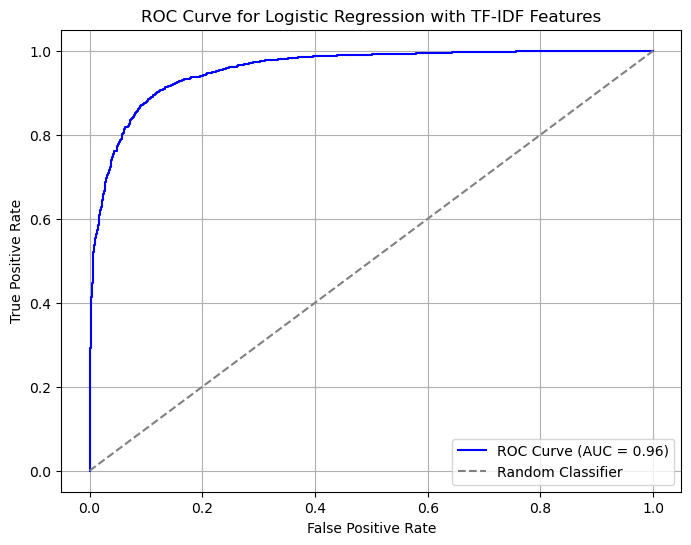

In [11]:
#9. Create a ROC curve for the test set.

# Predict TF-IDF features probability
y_prob_tfidf = log_reg_tfidf.predict_proba(X_test_tfidf)[:, 1]

# ROC Curve
fpr_tfidf, tpr_tfidf, _ = roc_curve(y_test, y_prob_tfidf)
auc_tfidf = roc_auc_score(y_test, y_prob_tfidf)

#plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_tfidf, tpr_tfidf, color='blue', label=f'ROC Curve (AUC = {auc_tfidf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')

plt.title('ROC Curve for Logistic Regression with TF-IDF Features')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [12]:
#10. Pick another classification model you learned about this week and repeat steps (5) – (9).

In [13]:
#5.2 - Initialize Random Forest Classifier

#Initialize Random Forest Classifier
rf_clf_tfidf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf_bow = RandomForestClassifier(n_estimators=200, random_state=42)

#Training Random Forest using TF-IDF features
rf_clf_tfidf.fit(X_train_tfidf, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [14]:
#6.2 Find the model accuracy on the test set.
# Making predictions and evaluating the model (TF-IDF)
y_pred_tfidf_rf = rf_clf_tfidf.predict(X_test_tfidf)
accuracy_tfidf_rf = accuracy_score(y_test, y_pred_tfidf_rf)
print(f"\n Random Forest (TF-IDF) Accuracy: {accuracy_tfidf_rf:.4f}")



 Random Forest (TF-IDF) Accuracy: 0.8542


In [15]:
#7.2 Create a confusion matrix for the test set predictions.

print("Confusion Matrix (TF-IDF):\n", confusion_matrix(y_test, y_pred_tfidf_rf))
rf_clf_tfidf.fit(X_train_tfidf, y_train)

Confusion Matrix (TF-IDF):
 [[2117  364]
 [ 365 2154]]


RandomForestClassifier(n_estimators=200, random_state=42)

In [16]:
#8.2 Get the precision, recall, and F1-score for the test set predictions.
print("Classification Report (TF-IDF):\n", classification_report(y_test, y_pred_tfidf_rf))

Classification Report (TF-IDF):
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      2481
           1       0.86      0.86      0.86      2519

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



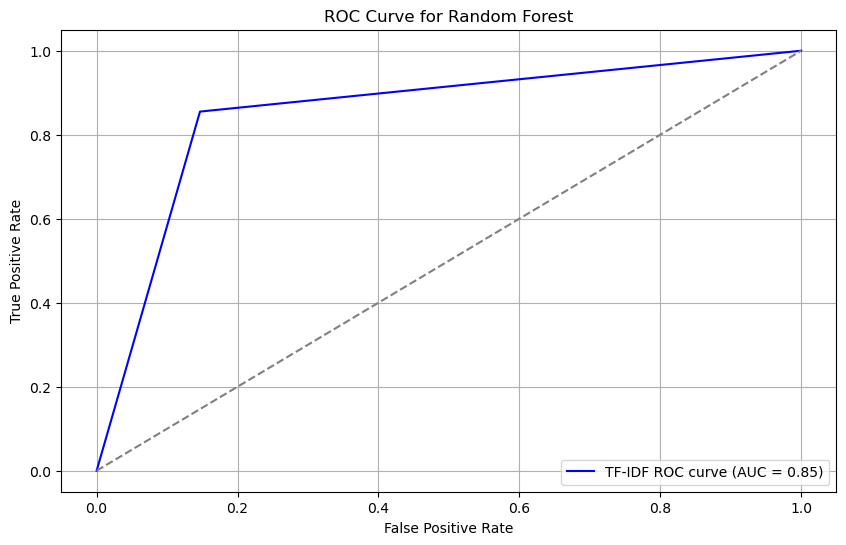

In [17]:
#9.2 Create a ROC curve for the test set.

# ROC Curve for TF-IDF
fpr_tfidf, tpr_tfidf, _ = roc_curve(y_test, y_pred_tfidf_rf )
auc_tfidf = roc_auc_score(y_test, y_pred_tfidf_rf )

# Plotting the ROC Curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_tfidf, tpr_tfidf, color='blue', label=f'TF-IDF ROC curve (AUC = {auc_tfidf:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.title('ROC Curve for Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()